In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from vis import (
    Plotter,
    _window_and_filter,
    load_embeddings_pt,
    centroids_by_token,
)

In [2]:
def parse_grid_text(text: str):
    """
    Restituisce una matrice di token (lista di liste), ignorando la riga '(griglia)' se presente.
    """
    lines = [ln.rstrip() for ln in text.splitlines() if ln.strip()]
    
    if lines and lines[0].strip().lower() == "(griglia)":
        lines = lines[1:]
    
    # Split su spazi multipli / whitespace
    rows = [ln.split() for ln in lines]
    
    # Validazione: tutte le righe con stesso numero di colonne
    ncols = len(rows[0])
    for r in rows:
        if len(r) != ncols:
            raise ValueError(f"Riga con numero colonne diverso: atteso {ncols}, trovato {len(r)} -> {r}")
    return rows

def grid_to_graph(rows, diagonals=False):
    """
    Costruisce un grafo non orientato da una griglia di parole.
    Connette vicini ortogonali (e diagonali se diagonals=True).
    """
    G = nx.Graph()
    nrows, ncols = len(rows), len(rows[0])
    
    # aggiungi nodi
    for i in range(nrows):
        for j in range(ncols):
            G.add_node(rows[i][j], pos=(i, j))
    
    # direzioni: destra e sotto bastano per non duplicare archi
    directions = [(0, 1), (1, 0)]
    if diagonals:
        directions += [(1, 1), (1, -1)]
    
    for i in range(nrows):
        for j in range(ncols):
            u = rows[i][j]
            for di, dj in directions:
                ni, nj = i + di, j + dj
                if 0 <= ni < nrows and 0 <= nj < ncols:
                    v = rows[ni][nj]
                    G.add_edge(u, v, weight=1.0)
    
    return G

TREE_BRANCH_RE = re.compile(r"(├──|└──)\s*(.+)$")

def parse_tree_text(text: str):
    """
    Converte un albero testuale Unicode in una lista di archi (parent, child).
    Restituisce (root, edges).
    
    Funziona con righe tipo:
    root
    ├── child1
    │   ├── grandchild
    └── child2
    """
    lines = [ln.rstrip("\n") for ln in text.splitlines() if ln.strip()]
    if not lines:
        raise ValueError("Testo vuoto")
    
    # prima riga: root (senza prefissi)
    root = lines[0].strip()
    edges = []
    
    # stack: depth -> node_name
    # depth = livello (0=root, 1 figli root, ...)
    stack = {0: root}
    
    for line in lines[1:]:
        # trova la parte con branch + label
        m = TREE_BRANCH_RE.search(line)
        if not m:
            # se il formato non è perfettamente standard, puoi gestire fallback qui
            raise ValueError(f"Riga non riconosciuta come ramo: {line!r}")
        
        label = m.group(2).strip()
        
        # Prefisso prima di ├── / └──
        prefix = line[:m.start()]
        
        # Nei tree unicode standard, ogni livello occupa 4 caratteri:
        # "│   " oppure "    "
        # Quindi la profondità del nodo = (len(prefix) // 4) + 1
        depth = (len(prefix) // 4) + 1
        
        parent_depth = depth - 1
        if parent_depth not in stack:
            raise ValueError(f"Parent non trovato per nodo {label!r} (depth={depth})")
        
        parent = stack[parent_depth]
        edges.append((parent, label))
        
        # aggiorna stack al depth corrente
        stack[depth] = label
        
        # pulizia eventuali depth più profondi non più validi
        to_delete = [d for d in stack if d > depth]
        for d in to_delete:
            del stack[d]
    
    return root, edges

def tree_to_graph(root, edges, directed=False):
    G = nx.DiGraph() if directed else nx.Graph()
    G.add_node(root)
    G.add_edges_from(edges, weight=1.0)
    return G

def load_graph_from_txt(path, kind="auto", diagonals=False, directed_tree=False):
    text = Path(path).read_text(encoding="utf-8")
    
    if kind == "auto":
        stripped = text.lstrip()
        if stripped.startswith("(griglia)"):
            kind = "grid"
        elif "├──" in text or "└──" in text:
            kind = "tree"
        else:
            raise ValueError("Impossibile inferire il formato. Usa kind='grid' o kind='tree'.")
    
    if kind == "grid":
        rows = parse_grid_text(text)
        return grid_to_graph(rows, diagonals=diagonals)
    elif kind == "tree":
        root, edges = parse_tree_text(text)
        return tree_to_graph(root, edges, directed=directed_tree)
    else:
        raise ValueError(f"Formato non supportato: {kind}")



In [8]:

def dirichlet_energy_laplacian(G, nodes, X, weight="weight"):
    """
    E = Tr(X^T L X)
    """
    L = nx.laplacian_matrix(G, nodelist=nodes, weight=weight)  # sparse matrix
    LX = L @ X
    E = float(np.trace(X.T @ LX))
    return E/np.linalg.norm(X, 'fro')**2  # normalizzazione per rendere l'energia indipendente dalla scala di X
import numpy as np

# def dirichlet_energy_edgewise(G, nodes, X, weight_attr="weight"):
#     """
#     E = 1/2 sum_{(i,j)} w_ij ||x_i - x_j||^2
#     Per grafi non orientati in networkx ogni arco appare una sola volta,
#     quindi puoi anche omettere il 1/2 a seconda della convenzione.
#     Qui uso la convenzione con somma su archi una sola volta -> NO 1/2.
#     """
#     idx = {node: k for k, node in enumerate(nodes)}
#     E = 0.0
#     for u, v, data in G.edges(data=True):
#         w = float(data.get(weight_attr, 1.0))
#         diff = X[idx[u]] - X[idx[v]]
#         E += w * float(np.dot(diff, diff))
#     return E

# grid

In [ ]:
VOCAB_PATH = Path("../data/uncorrelated-words/selected_llama31_layer0.txt")
# VOCAB_PATH = Path("../data/paper-tkid-map.txt")

EMB_DIR    = Path("../embeddings/data_3000/grid_16/")
GRID_PATH  = Path("../data/one_random_walk/grid_16/grid_dataset_structure.txt")

hp_grid = Plotter(VOCAB_PATH, GRID_PATH, EMB_DIR)

G = load_graph_from_txt(GRID_PATH, kind="grid")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)  # layout automatico
nx.draw(
    G, pos,
    with_labels=True,
    node_size=600,
    font_size=9
)
plt.show()

In [ ]:
ctx = 3000
WIN = 200          # ampiezza finestra interna

all_results = []   # lista di dict: uno per finestra

pt_path = EMB_DIR / f"reprs_grid_dataset_one_rw_{ctx}_line000000_layer26.pt"
ids_np, emb_np = load_embeddings_pt(pt_path)

T_file = len(ids_np)  # numero token effettivamente presenti nel file (<= 500, spesso 500)
file_global_start = max(0, ctx - T_file)   # inizio globale coperto dal file
file_global_end = ctx                       # fine globale esclusiva

print(f"\n=== CTX={ctx} | file_len={T_file} | global_range=[{file_global_start}:{file_global_end}) ===")

# finestre locali nel file: [0:100), [100:200), ...
for t0 in range(0, T_file, WIN):
    t1 = min(t0 + WIN, T_file)

    # range globale corrispondente (solo per logging/debug)
    g0 = file_global_start + t0
    g1 = file_global_start + t1

    filtered_ids, filtered_emb = _window_and_filter(
        ids_np, emb_np, hp_grid.id_to_word,
        k=50,
        t_start=t0, t_end=t1,
        title=f"ctx={ctx}, local=[{t0}:{t1}), global=[{g0}:{g1})"
    )

    # se non c'è nulla dopo il filtro, salta
    if len(filtered_ids) == 0:
        print(f"  [ctx={ctx}] window local=[{t0}:{t1}) global=[{g0}:{g1}) -> vuota dopo filtro")
        all_results.append({
            "ctx": ctx,
            "t_start_local": t0, "t_end_local": t1,
            "t_start_global": g0, "t_end_global": g1,
            "energy": np.nan,
            "n_filtered": 0,
            "n_centroids": 0,
        })
        continue

    centroid_ids, centroids = centroids_by_token(filtered_ids, filtered_emb)

    # se per qualche motivo non hai centroidi
    if len(centroid_ids) == 0:
        print(f"  [ctx={ctx}] window local=[{t0}:{t1}) -> nessun centroide")
        all_results.append({
            "ctx": ctx,
            "t_start_local": t0, "t_end_local": t1,
            "t_start_global": g0, "t_end_global": g1,
            "energy": np.nan,
            "n_filtered": len(filtered_ids),
            "n_centroids": 0,
        })
        continue

    X = centroids.astype(np.float64).copy()
    X = X - X.mean(axis=0, keepdims=True)  # center per feature
    X = X / np.clip(X.std(axis=0, keepdims=True), 1e-8, None)  # std per feature

    labels = [hp_grid.id_to_word.get(int(t), str(int(t))) for t in centroid_ids]

    # opzionale ma molto utile: allinea al grafo (se nella finestra mancano nodi)
    common = [lab for lab in labels if lab in G.nodes()]
    if len(common) < 2:
        print(f"  [ctx={ctx}] window [{g0}:{g1}) -> troppo pochi nodi comuni al grafo ({len(common)})")
        E = np.nan
    else:
        idx = {lab: i for i, lab in enumerate(labels)}
        X_common = np.stack([X[idx[lab]] for lab in common], axis=0)

        # subgrafo indotto sui nodi presenti nella finestra
        G_sub = G.subgraph(common).copy()

        # se non ci sono archi nel subgrafo, energia non informativa
        if G_sub.number_of_edges() == 0:
            E = np.nan
            print(f"  [ctx={ctx}] window [{g0}:{g1}) -> subgrafo senza archi")
        else:
            E = dirichlet_energy_laplacian(G_sub, common, X_common)

    print(f"  CTX={ctx} | local=[{t0}:{t1}) | global=[{g0}:{g1}) | E={E}")

    all_results.append({
        "ctx": ctx,
        "t_start_local": t0, "t_end_local": t1,
        "t_start_global": g0, "t_end_global": g1,
        "energy": E,
        "n_filtered": len(filtered_ids),
        "n_centroids": len(centroid_ids),
    })

In [ ]:


# 1) DataFrame
df = pd.DataFrame(all_results)

# 2) Togli finestre senza energia
df_plot = df.dropna(subset=["energy"]).copy()

# 3) Ordina (sempre meglio)
df_plot = df_plot.sort_values(["ctx", "t_end_global"])

# 4) Plot: una curva per ciascun CTX
plt.figure(figsize=(9, 5))

for ctx, d in df_plot.groupby("ctx"):
    plt.plot(d["t_end_global"][:-1], d["energy"][:-1], marker="o", label=f"ctx={ctx}")

plt.xlabel("t_end_global")
plt.ylabel("Dirichlet energy")
# plt.xscale("log")  # scala logaritmica per evidenziare differenze
plt.title("Energia vs t_end_global")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# tree

Grid - #nodi: 31 #archi: 30


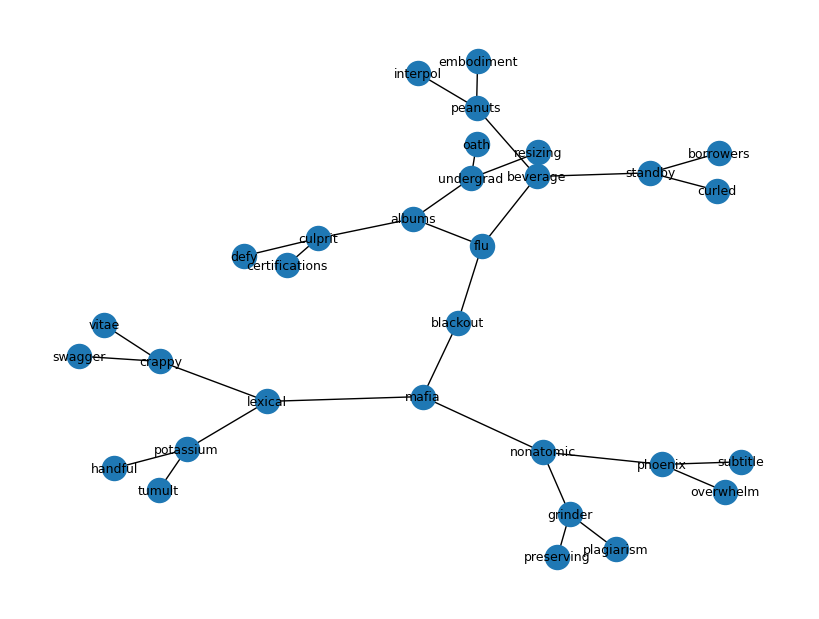

In [3]:
TREE_PATH  = Path("../data/one_random_walk/tree_4_levels/bin_tree_structure.txt")
G = load_graph_from_txt(TREE_PATH, kind="tree")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)  # layout automatico
nx.draw(
    G, pos,
    with_labels=True,
    node_size=300,
    font_size=9
)
plt.show()

In [11]:
VOCAB_PATH = Path("../data/uncorrelated-words/selected_llama31_layer0.txt")
STRUCT_PATH = Path("../data/one_random_walk/tree_4_levels/bin_tree_structure.txt")
EMB_DIR     = Path("../embeddings/tree_4_levels/")
hp_tree_das = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)


In [12]:
ctx = 3000 
l=31
WIN = 300          # ampiezza finestra interna

all_results = []   # lista di dict: uno per finestra

pt_path = EMB_DIR / f"reprs_bin_tree_one_rw_{ctx}_line000000_layer{l}.pt"
ids_np, emb_np = load_embeddings_pt(pt_path)

T_file = len(ids_np)  # numero token effettivamente presenti nel file (<= 500, spesso 500)
file_global_start = max(0, ctx - T_file)   # inizio globale coperto dal file
file_global_end = ctx                       # fine globale esclusiva

print(f"\n=== CTX={ctx} | file_len={T_file} | global_range=[{file_global_start}:{file_global_end}) ===")

# finestre locali nel file: [0:100), [100:200), ...
for t0 in range(0, T_file, WIN):
    t1 = min(t0 + WIN, T_file)

    # range globale corrispondente (solo per logging/debug)
    g0 = file_global_start + t0
    g1 = file_global_start + t1

    filtered_ids, filtered_emb = _window_and_filter(
        ids_np, emb_np, hp_tree_das.id_to_word,
        k=50,
        t_start=t0, t_end=t1,
        title=f"ctx={ctx}, local=[{t0}:{t1}), global=[{g0}:{g1})"
    )

    # se non c'è nulla dopo il filtro, salta
    if len(filtered_ids) == 0:
        print(f"  [ctx={ctx}] window local=[{t0}:{t1}) global=[{g0}:{g1}) -> vuota dopo filtro")
        all_results.append({
            "ctx": ctx,
            "t_start_local": t0, "t_end_local": t1,
            "t_start_global": g0, "t_end_global": g1,
            "energy": np.nan,
            "n_filtered": 0,
            "n_centroids": 0,
        })
        continue

    centroid_ids, centroids = centroids_by_token(filtered_ids, filtered_emb)

    # se per qualche motivo non hai centroidi
    if len(centroid_ids) == 0:
        print(f"  [ctx={ctx}] window local=[{t0}:{t1}) -> nessun centroide")
        all_results.append({
            "ctx": ctx,
            "t_start_local": t0, "t_end_local": t1,
            "t_start_global": g0, "t_end_global": g1,
            "energy": np.nan,
            "n_filtered": len(filtered_ids),
            "n_centroids": 0,
        })
        continue

    X = centroids.astype(np.float64).copy()
    X = X - X.mean(axis=0, keepdims=True)  # center per feature
    X = X / np.clip(X.std(axis=0, keepdims=True), 1e-8, None)  # std per feature

    labels = [hp_tree_das.id_to_word.get(int(t), str(int(t))) for t in centroid_ids]

    # opzionale ma molto utile: allinea al grafo (se nella finestra mancano nodi)
    common = [lab for lab in labels if lab in G.nodes()]
    if len(common) < 2:
        print(f"  [ctx={ctx}] window [{g0}:{g1}) -> troppo pochi nodi comuni al grafo ({len(common)})")
        E = np.nan
    else:
        idx = {lab: i for i, lab in enumerate(labels)}
        X_common = np.stack([X[idx[lab]] for lab in common], axis=0)

        # subgrafo indotto sui nodi presenti nella finestra
        G_sub = G.subgraph(common).copy()

        # se non ci sono archi nel subgrafo, energia non informativa
        if G_sub.number_of_edges() == 0:
            E = np.nan
            print(f"  [ctx={ctx}] window [{g0}:{g1}) -> subgrafo senza archi")
        else:
            E = dirichlet_energy_laplacian(G_sub, common, X_common)

    print(f"  CTX={ctx} | local=[{t0}:{t1}) | global=[{g0}:{g1}) | E={E}")

    all_results.append({
        "ctx": ctx,
        "t_start_local": t0, "t_end_local": t1,
        "t_start_global": g0, "t_end_global": g1,
        "energy": E,
        "n_filtered": len(filtered_ids),
        "n_centroids": len(centroid_ids),
    })


=== CTX=3000 | file_len=3001 | global_range=[0:3000) ===
  [ctx=3000, local=[0:300), global=[0:300)] Warning: token 'handful' has only 9 occurrences in [0:300] (requested 50)
  [ctx=3000, local=[0:300), global=[0:300)] Warning: token 'plagiarism' has only 4 occurrences in [0:300] (requested 50)
  [ctx=3000, local=[0:300), global=[0:300)] Warning: token 'certifications' has only 6 occurrences in [0:300] (requested 50)
  [ctx=3000, local=[0:300), global=[0:300)] Warning: token 'flu' has only 8 occurrences in [0:300] (requested 50)
  [ctx=3000, local=[0:300), global=[0:300)] Warning: token 'oath' has only 7 occurrences in [0:300] (requested 50)
  [ctx=3000, local=[0:300), global=[0:300)] Warning: token 'culprit' has only 19 occurrences in [0:300] (requested 50)
  [ctx=3000, local=[0:300), global=[0:300)] Warning: token 'undergrad' has only 17 occurrences in [0:300] (requested 50)
  [ctx=3000, local=[0:300), global=[0:300)] Warning: token 'crappy' has only 13 occurrences in [0:300] (reque

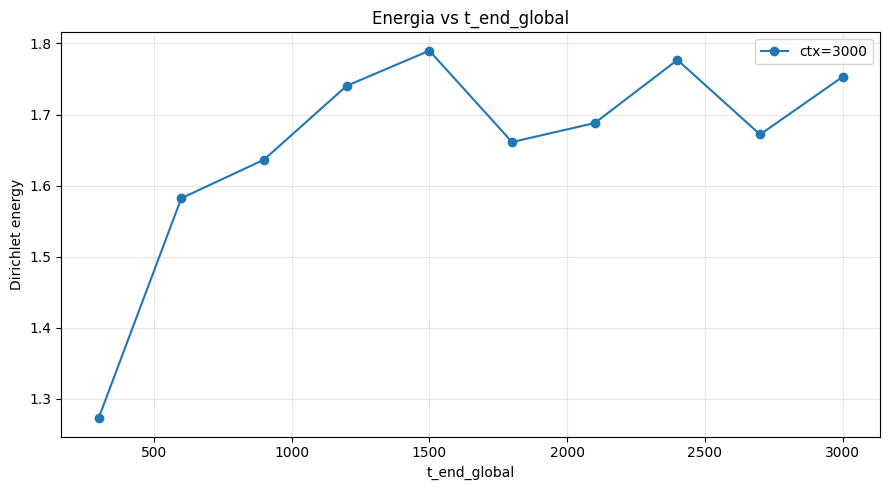

In [13]:
# 1) DataFrame
df = pd.DataFrame(all_results)

# 2) Togli finestre senza energia
df_plot = df.dropna(subset=["energy"]).copy()

# 3) Ordina (sempre meglio)
df_plot = df_plot.sort_values(["ctx", "t_end_global"])

# 4) Plot: una curva per ciascun CTX
plt.figure(figsize=(9, 5))

for ctx, d in df_plot.groupby("ctx"):
    plt.plot(d["t_end_global"], d["energy"], marker="o", label=f"ctx={ctx}")

plt.xlabel("t_end_global")
plt.ylabel("Dirichlet energy")
plt.title("Energia vs t_end_global")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# clustered tree

In [ ]:
clustered_tree = """
root
├── c1.1
│   ├── c2.1
│   │   ├── c3.1
│   │   └── c3.2
│   └── c2.2
│       ├── c3.3
│       └── c3.4
└── c1.2
    ├── c2.3
    │   ├── c3.5
    │   └── c3.6
    └── c2.4
        ├── c3.7
        └── c3.8
"""

cluster_to_words = {
    "root": ("blackout", "vitae", "swagger"),

    "c1.1": ("mafia", "tumult", "handful"),
    "c1.2": ("flu", "overwhelm", "subtitle"),

    "c2.1": ("lexical", "preserving", "plagiarism"),
    "c2.2": ("nonatomic", "borrowers", "curled"),
    "c2.3": ("beverage", "embodiment", "interpol"),
    "c2.4": ("albums", "resizing", "oath"),

    "c3.1": ("crappy", "defy", "certifications"),
    "c3.2": ("potassium", "albeit", "mote"),
    "c3.3": ("phoenix", "tasty", "wealthiest"),
    "c3.4": ("grinder", "unconditional", "intends"),
    "c3.5": ("standby", "flaming", "fabs"),
    "c3.6": ("peanuts", "stricter", "improvised"),
    "c3.7": ("undergrad", "soar", "finns"),
    "c3.8": ("culprit", "righteous", "intimately"),
}

In [ ]:
root_c, edges_c = parse_tree_text(clustered_tree)
G_cluster = tree_to_graph(root_c, edges_c, directed=False)

In [ ]:
import numpy as np

def build_word_centroid_map(centroid_ids, centroids, id_to_word):
    """
    Restituisce dict: parola -> vettore centroid
    """
    word_to_centroid = {}
    for tid, vec in zip(centroid_ids, centroids):
        w = id_to_word.get(int(tid), str(int(tid)))
        word_to_centroid[w] = np.asarray(vec, dtype=np.float64)
    return word_to_centroid

def aggregate_cluster_centroids(G_cluster, cluster_to_words, word_to_centroid, agg="mean"):
    """
    Costruisce X (n_cluster, d) allineato ai nodi di G_cluster.
    Restituisce (cluster_labels, X)
    """
    cluster_labels = list(G_cluster.nodes())
    X = []

    missing = {}

    for c in cluster_labels:
        if c not in cluster_to_words:
            raise KeyError(f"Cluster {c!r} non presente in cluster_to_words")

        words = cluster_to_words[c]
        vecs = []
        miss = []

        for w in words:
            if w in word_to_centroid:
                vecs.append(word_to_centroid[w])
            else:
                miss.append(w)

        if miss:
            missing[c] = miss

        if len(vecs) == 0:
            raise ValueError(f"Nessun embedding disponibile per cluster {c!r} (words={words})")

        M = np.stack(vecs, axis=0)
        if agg == "mean":
            xc = M.mean(axis=0)
        elif agg == "sum":
            xc = M.sum(axis=0)
        else:
            raise ValueError("agg deve essere 'mean' o 'sum'")

        X.append(xc)

    if missing:
        print("Attenzione: parole mancanti in alcuni cluster:")
        for c, miss in missing.items():
            print(f"  {c}: {miss}")

    X = np.stack(X, axis=0).astype(np.float64)
    return cluster_labels, X

In [ ]:
CTX_LENS = [300, 600, 1200, 1800]
EMB_DIR     = Path("../embeddings/one_random_walk/tree_clusters_3_levels/")

# 1) costruisci una volta il grafo clustered
root_c, edges_c = parse_tree_text(clustered_tree)
G_cluster = tree_to_graph(root_c, edges_c, directed=False)

# check coerenza mappa cluster -> parole
assert set(cluster_to_words.keys()) == set(G_cluster.nodes()), (
    f"Mismatch cluster labels.\n"
    f"Solo in mappa: {set(cluster_to_words.keys()) - set(G_cluster.nodes())}\n"
    f"Solo nel grafo: {set(G_cluster.nodes()) - set(cluster_to_words.keys())}"
)

energies = []

for ctx in CTX_LENS:
    pt_path = EMB_DIR / f"reprs_bin_tree_cluster_one_rw_{ctx}_line000000_layer26.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    filtered_ids, filtered_emb = _window_and_filter(ids_np, emb_np, hp_grid.id_to_word, k=10)
    centroid_ids, centroids = centroids_by_token(filtered_ids, filtered_emb)

    # 2) dizionario parola -> centroide parola
    word_to_centroid = build_word_centroid_map(centroid_ids, centroids, hp_grid.id_to_word)

    # 3) aggrega ai cluster (un vettore per nodo del grafo clustered)
    cluster_labels, X_cluster = aggregate_cluster_centroids(
        G_cluster=G_cluster,
        cluster_to_words=cluster_to_words,
        word_to_centroid=word_to_centroid,
        agg="mean",   # root = media dei vettori delle parole nel tuple
    )

    # # 4) standardizzazione (come nel paper, per-feature)
    # X_cluster = X_cluster.astype(np.float64).copy()
    # X_cluster = X_cluster - X_cluster.mean(axis=0, keepdims=True)                 # center per feature
    # X_cluster = X_cluster / np.clip(X_cluster.std(axis=0, keepdims=True), 1e-8, None)   

    # 5) energia sul grafo clustered
    E = dirichlet_energy_laplacian(G_cluster, cluster_labels, X_cluster)

    # (opzionale) metriche normalizzate per confronti
    m = G_cluster.number_of_edges()
    d = X_cluster.shape[1]
    E_per_edge = E / m
    E_per_edge_dim = E / (m * d)

    print(f"[ctx={ctx}] E={E:.6f}  E/|E|={E_per_edge:.6f}  E/(|E|d)={E_per_edge_dim:.8f}")
    energies.append(E)

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(CTX_LENS, energies, marker="o")
plt.title("Dirichlet Energy vs Context Length")
plt.xlabel("Context Length")
plt.xscale("log")
plt.ylabel("Dirichlet Energy")
plt.grid(True)
plt.show()